In [1]:
import os


In [3]:
os.getcwd()

'C:\\Users\\Pratham'

In [40]:
import pandas as pd

In [41]:
df = pd.read_csv('./SMSSpamCollection', sep= '\t', names=['label','text'])

In [42]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
!pip install nltk
import nltk as nltk


[notice] A new release of pip available: 22.3 -> 22.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pratham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
sent = "How are you friends?"
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pratham\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [10]:
from nltk.tokenize import word_tokenize
word_tokenize(sent)

['How', 'are', 'you', 'friends', '?']

In [12]:
from nltk.corpus import stopwords
swords = stopwords.words("English")

In [13]:
clean = [word for word in word_tokenize(sent) if word not in swords]

In [14]:
clean

['How', 'friends', '?']

In [16]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
clean = [ps.stem(word) for word in word_tokenize(sent) if word not in swords]

In [17]:
clean

['how', 'friend', '?']

In [21]:
def clean_text(sent):
    tokens = word_tokenize(sent)
    clean = [ps.stem(word) for word in word_tokenize(sent) if word not in swords]
    return clean

In [22]:
clean_text(sent)

['how', 'friend', '?']

In [23]:
sent = "Hello friends! How are you? We will learning python today"

In [28]:
clean = [word for word in word_tokenize(sent) if word not in swords]
clean

['Hello', 'friends', '!', 'How', '?', 'We', 'learning', 'python', 'today']

In [32]:
def clean_text(sent):
    tokens = word_tokenize(sent)
    clean = [word for word in tokens if word.isdigit() or word.isalpha()]
    clean = [ps.stem(word) for word in clean if word not in swords]
    return clean

In [33]:
clean_text(sent)

['hello', 'friend', 'how', 'we', 'learn', 'python', 'today']

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(analyzer=clean_text)


In [43]:
x = df['text']
y = df['label']

In [44]:
x_new = tfidf.fit_transform(x)

In [45]:
x_new.shape


(5572, 6513)

In [55]:
y.value_counts()

ham     4825
spam     747
Name: label, dtype: int64

In [56]:
from sklearn.model_selection import train_test_split

In [58]:
x_train,x_test,y_train,y_test = train_test_split(x_new,y,test_size = 0.25 , random_state = 0)

In [60]:
from sklearn.naive_bayes import GaussianNB

In [61]:
nb = GaussianNB()

In [63]:
nb.fit(x_train.toarray(), y_train)

GaussianNB()

In [64]:
y_pred = nb.predict(x_test.toarray())

In [66]:
y_test.value_counts()

ham     1208
spam     185
Name: label, dtype: int64

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

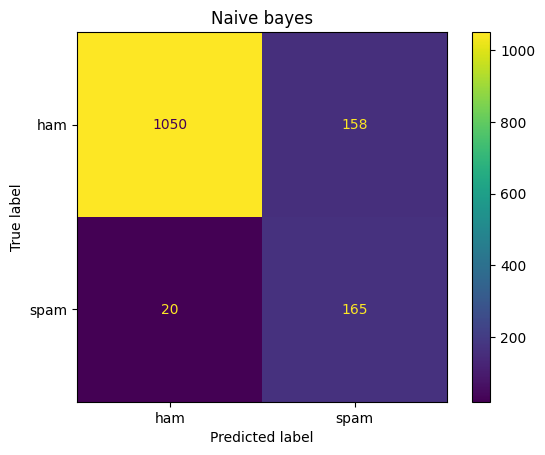

 Accuracy is 0.8722182340272793
              precision    recall  f1-score   support

         ham       0.98      0.87      0.92      1208
        spam       0.51      0.89      0.65       185

    accuracy                           0.87      1393
   macro avg       0.75      0.88      0.79      1393
weighted avg       0.92      0.87      0.89      1393



In [70]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title('Naive bayes')
plt.show()
print(f" Accuracy is {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

In [71]:
from sklearn.tree import DecisionTreeClassifier

In [72]:
dt = DecisionTreeClassifier(random_state = 0)

In [73]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=0)

In [80]:
y_pred_dt = dt.predict(x_test)

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay , classification_report

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      1208
        spam       0.85      0.86      0.86       185

    accuracy                           0.96      1393
   macro avg       0.91      0.92      0.92      1393
weighted avg       0.96      0.96      0.96      1393



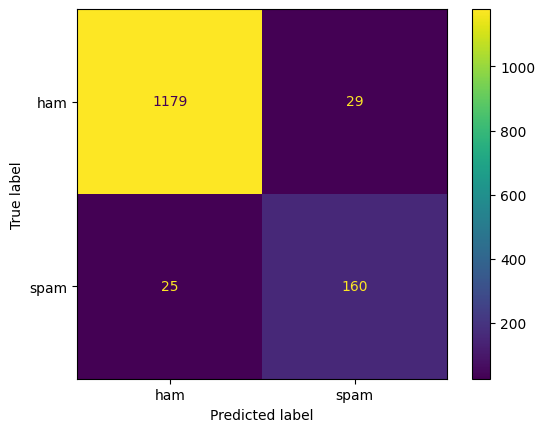

In [85]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
print(classification_report(y_test,y_pred_dt))

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
rf = RandomForestClassifier(random_state=1)

In [88]:
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=1)

In [89]:
y_pred_rf = rf.predict(x_test)

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.85      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393

0.9791816223977028


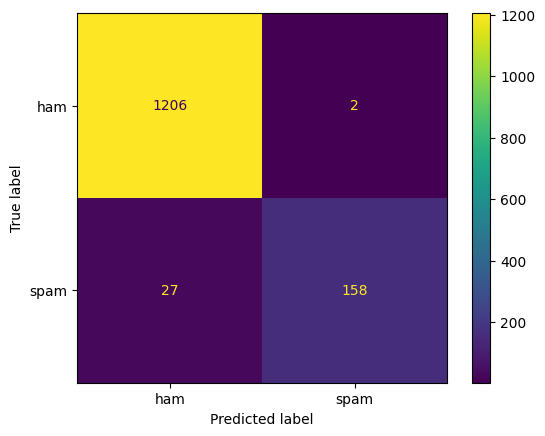

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
print(classification_report(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_rf))

In [95]:
from sklearn.model_selection import GridSearchCV


In [96]:
para = {
    'criterion':['gini', 'entropy','log_loss'],
    'max_features': ['sqrt','log2'],
    'random_state': [0,1,2,3,4],
    'class_weight':['balanced','balanced_subsample']
}

In [98]:
grid = GridSearchCV(rf, param_grid=para, cv=5, scoring='accuracy')

In [99]:
grid.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_features': ['sqrt', 'log2'],
                         'random_state': [0, 1, 2, 3, 4]},
             scoring='accuracy')

In [ ]:
rf = grid.best_estimator_

In [ ]:
y_pred_grid = rf.predict(x_test)


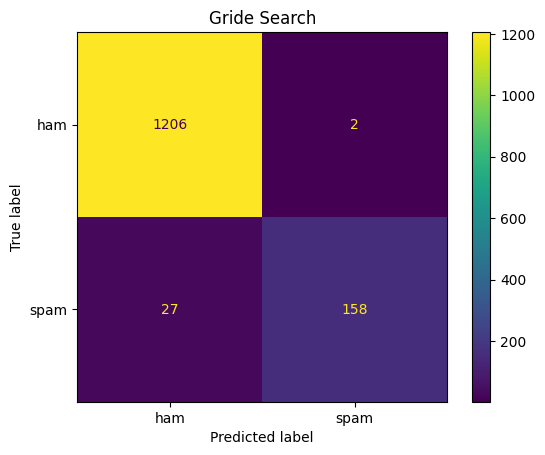

 Accuracy is 0.9791816223977028
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.85      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_grid)
plt.title('Gride Search')
plt.show()
print(f" Accuracy is {accuracy_score(y_test,y_pred_grid)}")
print(classification_report(y_test,y_pred_grid))